In [2]:
import pandas as pd
stats_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/AGeneratefulldf/intermittedly.csv")

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_stat(col, stats_df, station_col="station"):
    # basic cleaning
    df = stats_df[[station_col, "lon", "lat", col]].copy()
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[station_col, "lon", "lat", col])

    # --- aggregate per station ---
    plot_df = (
        df.groupby(station_col)
          .agg({
              "lon": "mean",   # safe if constant per station
              "lat": "mean",
              col: "mean"
          })
          .reset_index()
    )

    # --- map ---
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(10, 8))
    ax = plt.axes(projection=ccrs.Mercator())

    pad = 2
    ax.set_extent(
        [plot_df["lon"].min()-pad, plot_df["lon"].max()+pad,
         plot_df["lat"].min()-pad, plot_df["lat"].max()+pad],
        crs=proj
    )

    ax.add_feature(cfeature.LAND, zorder=0)
    ax.add_feature(cfeature.OCEAN, zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

    sc = ax.scatter(
        plot_df["lon"], plot_df["lat"],
        c=plot_df[col],
        s=30,
        transform=proj
    )

    cb = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.03)
    cb.set_label(f"Mean {col}")

    ax.set_title(f"Mean {col} per station")
    plt.show()

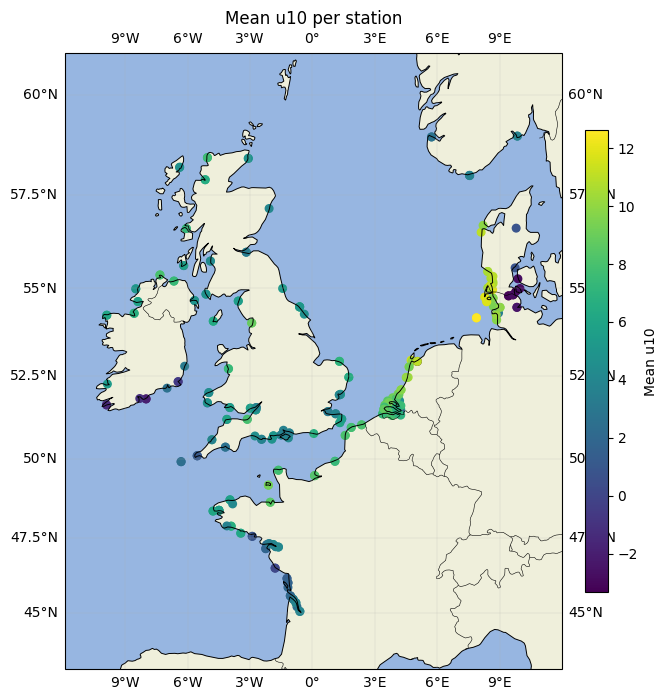

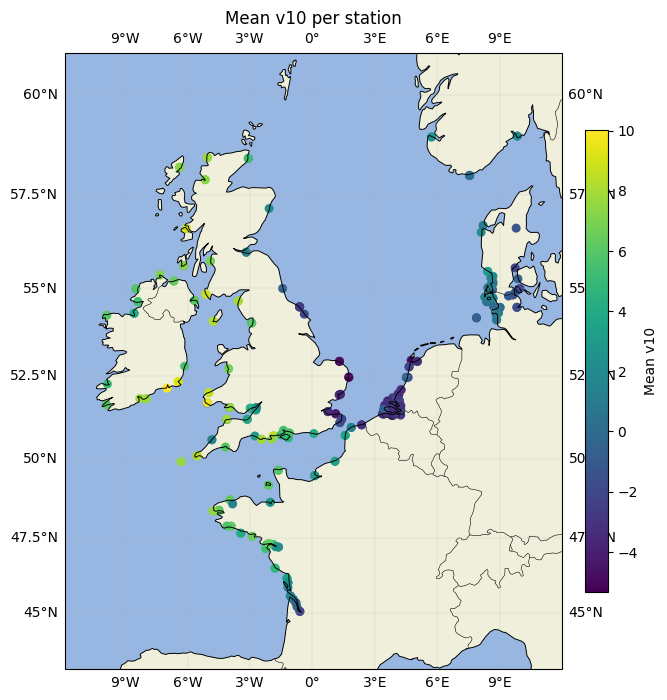

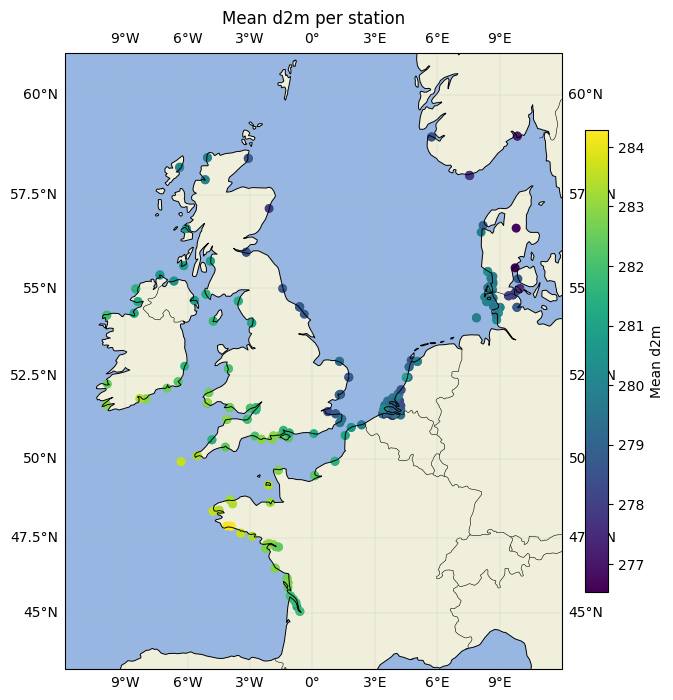

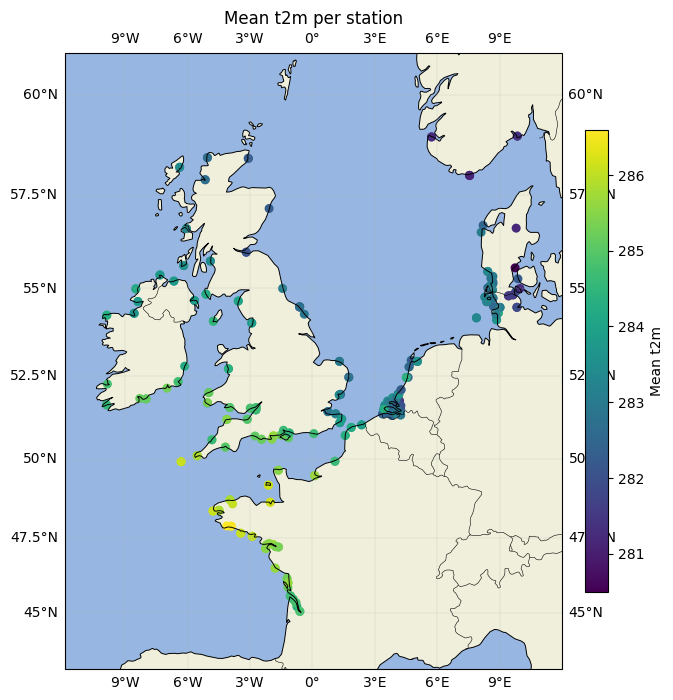

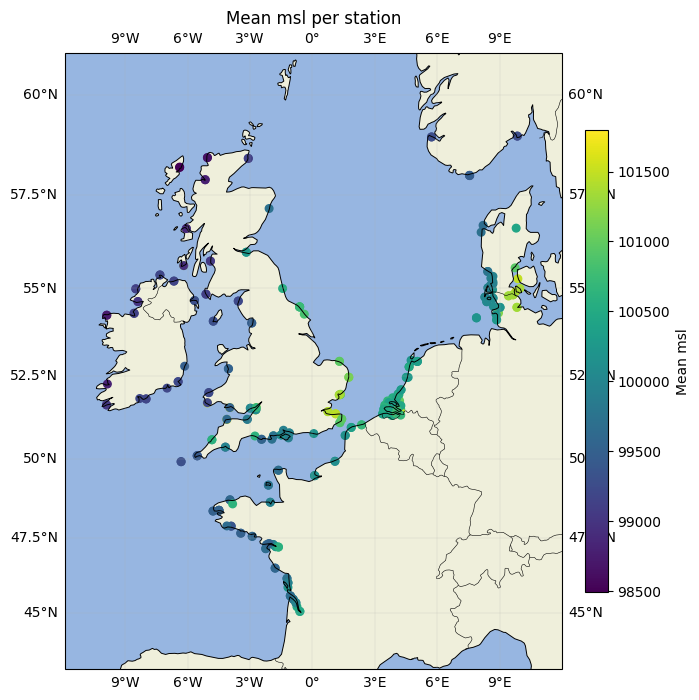

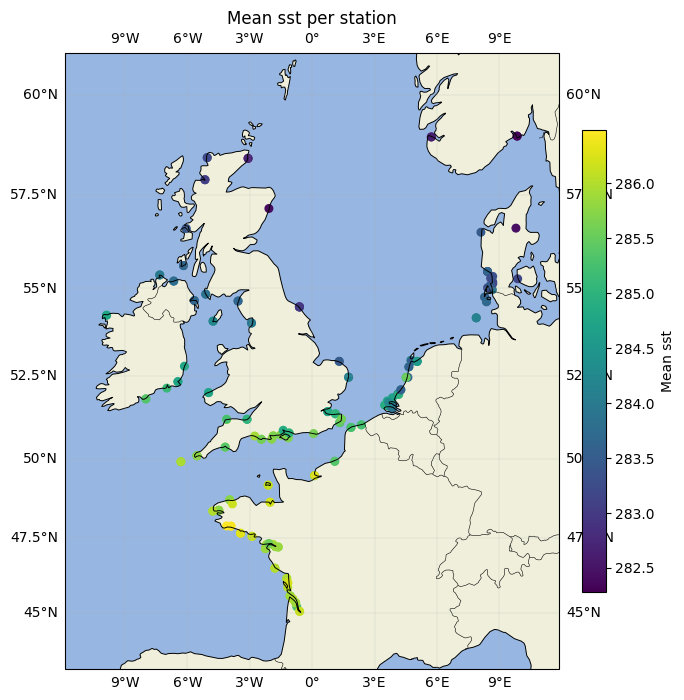

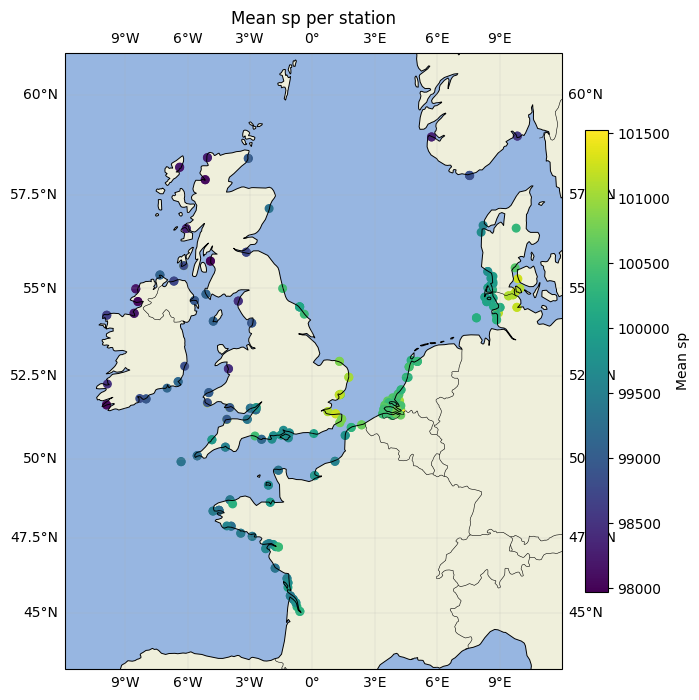

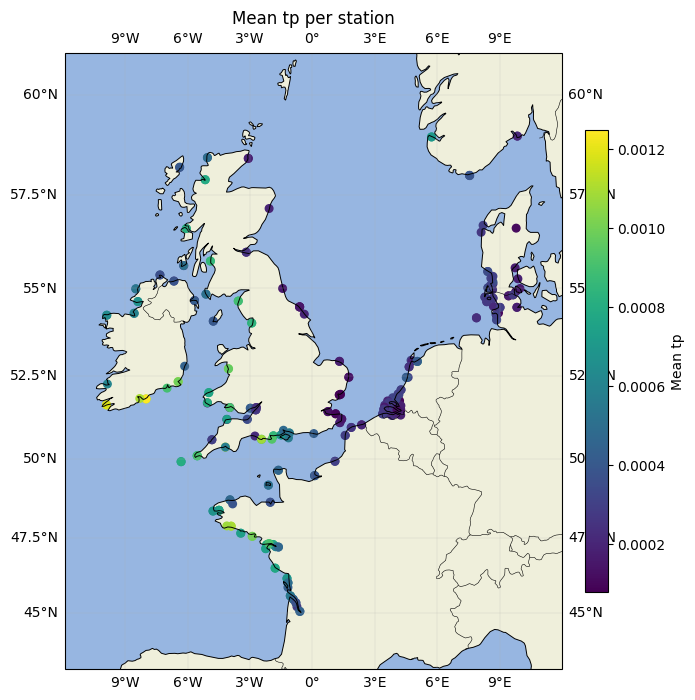

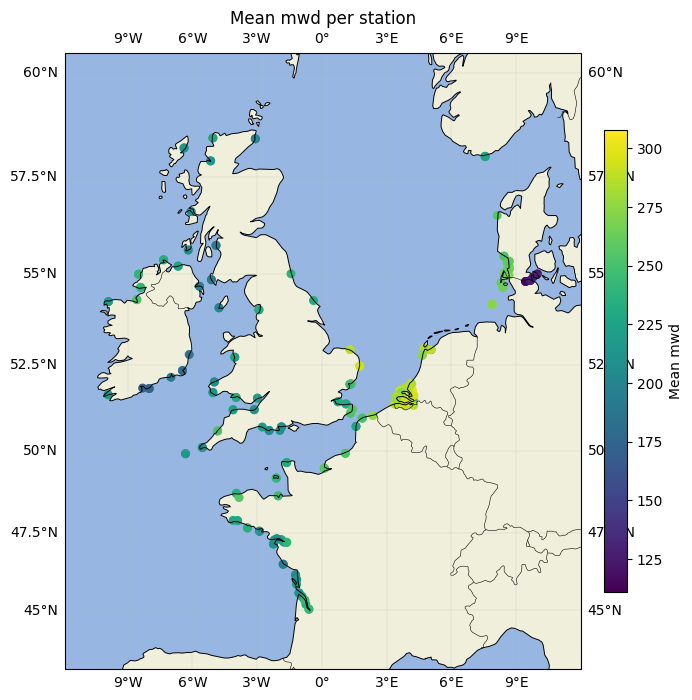

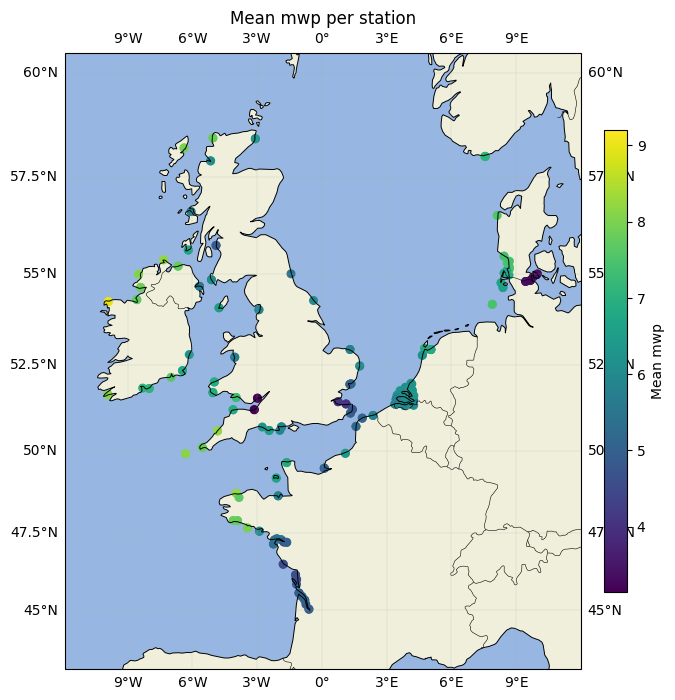

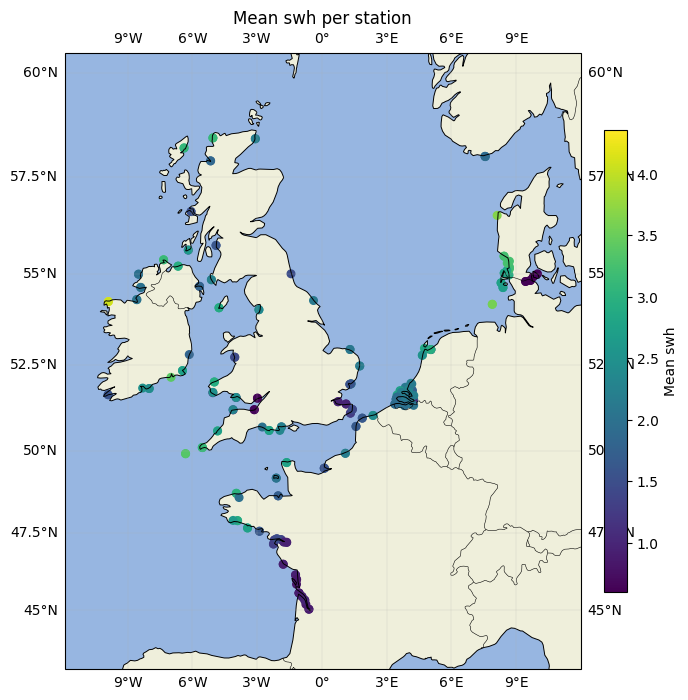

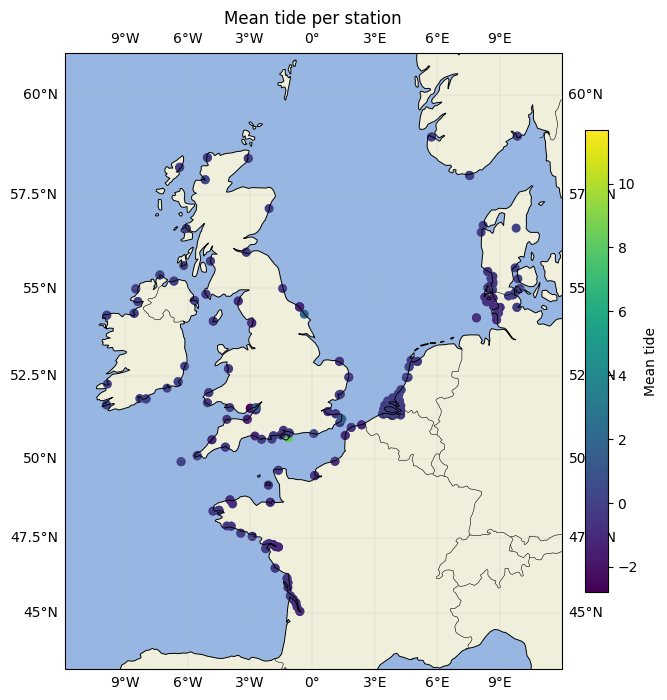

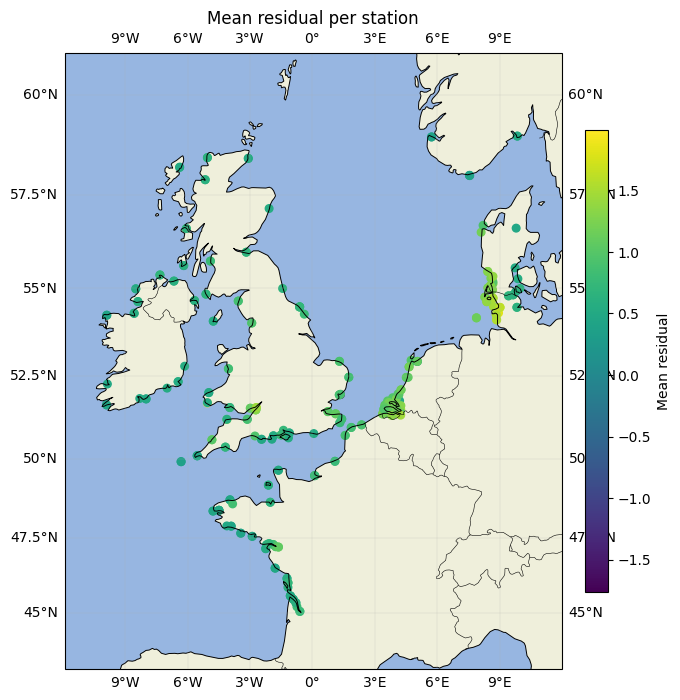

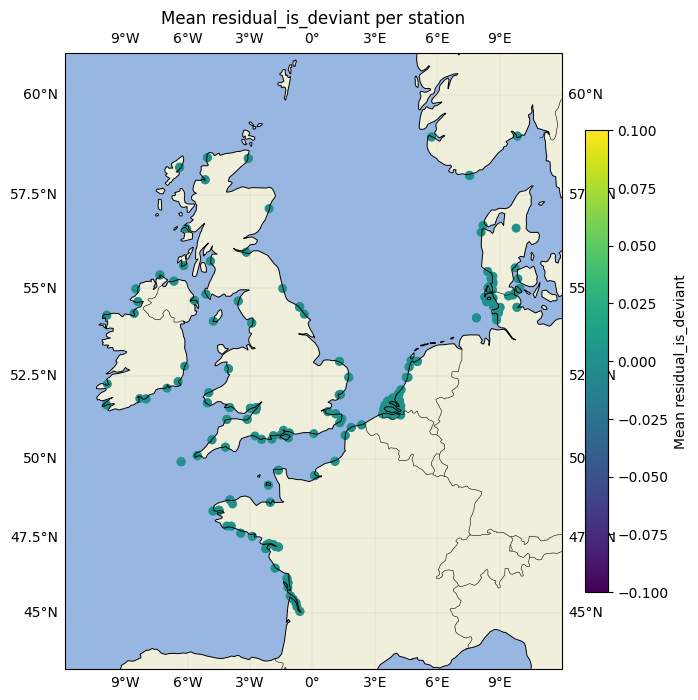

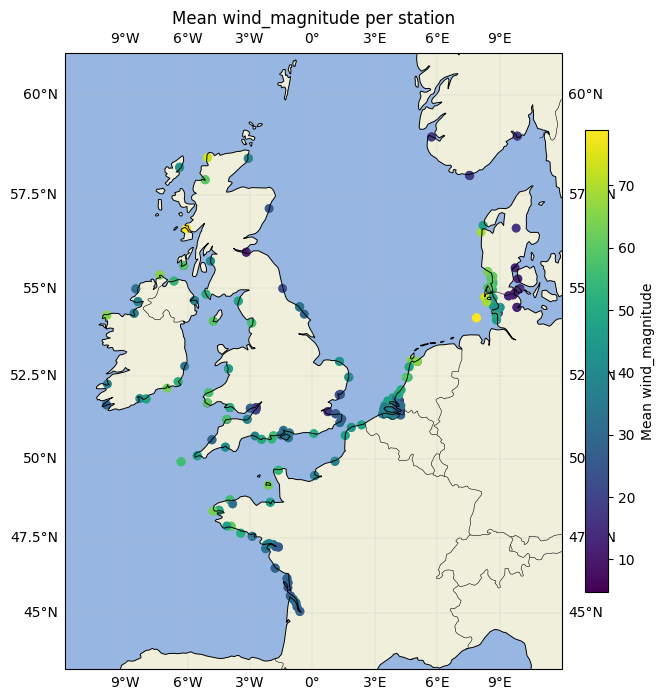

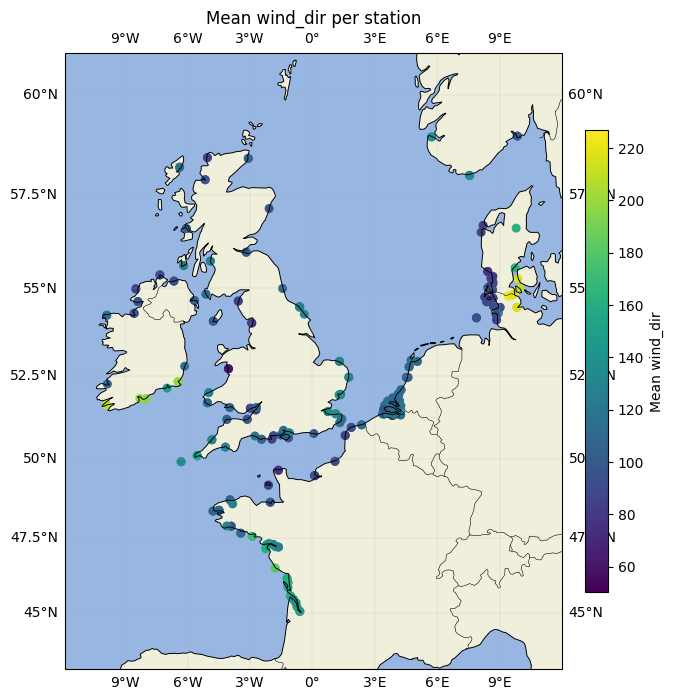

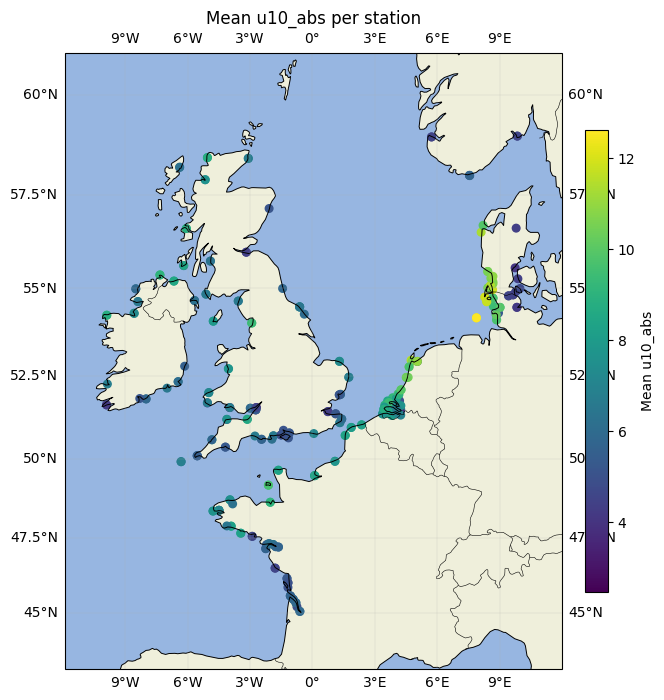

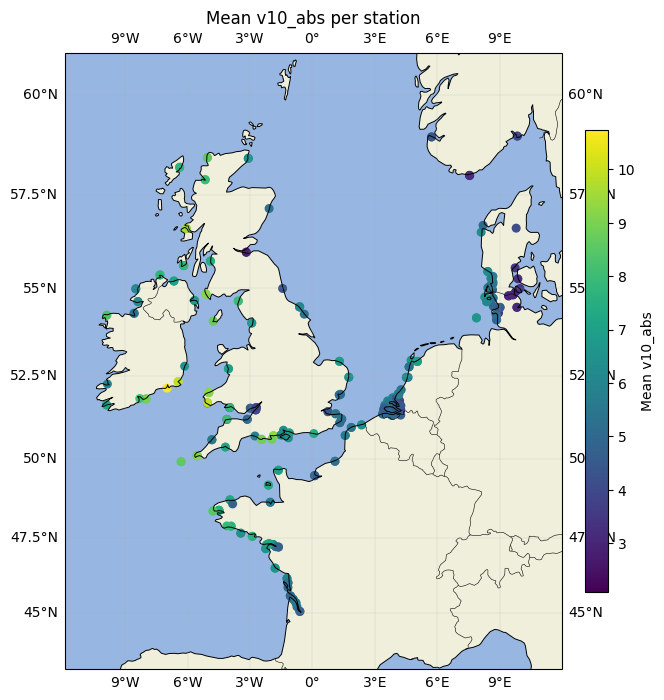

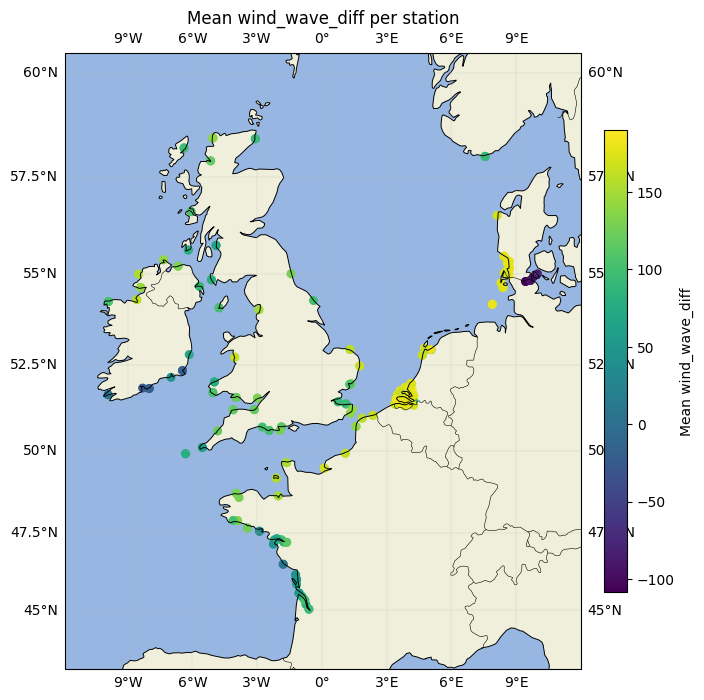

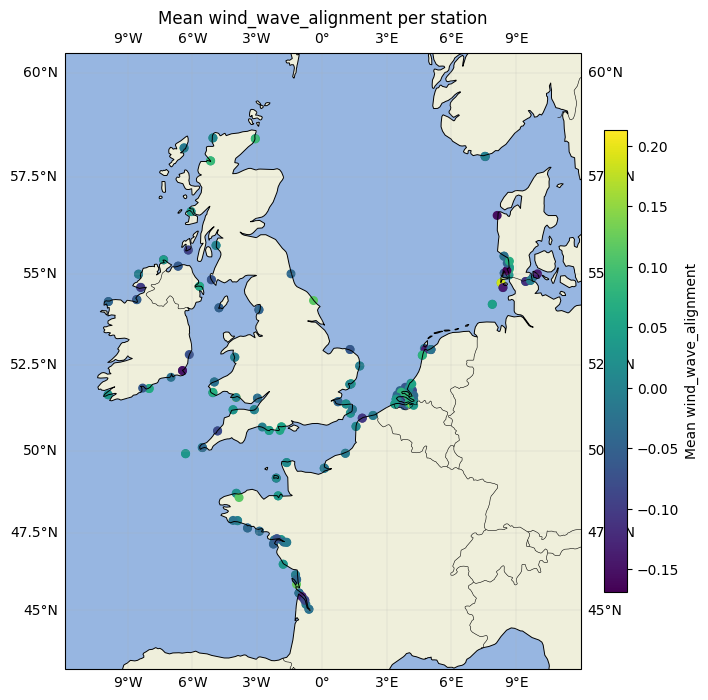

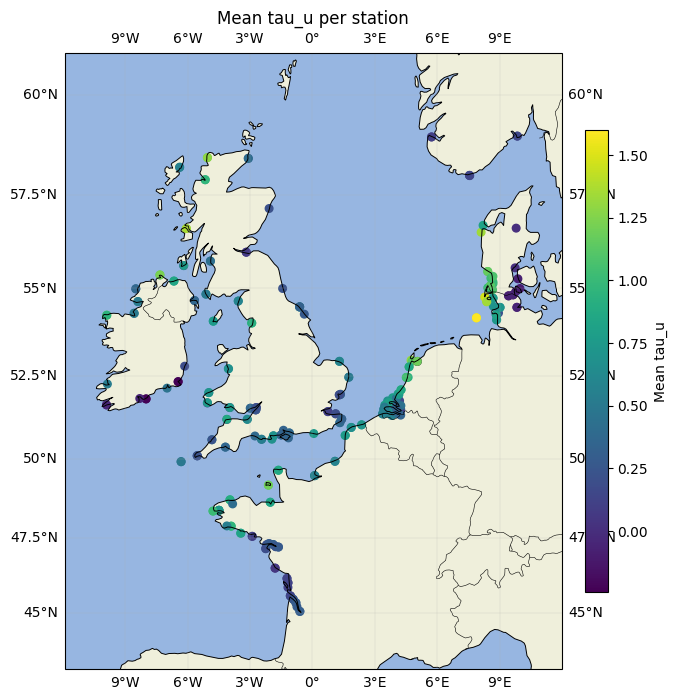

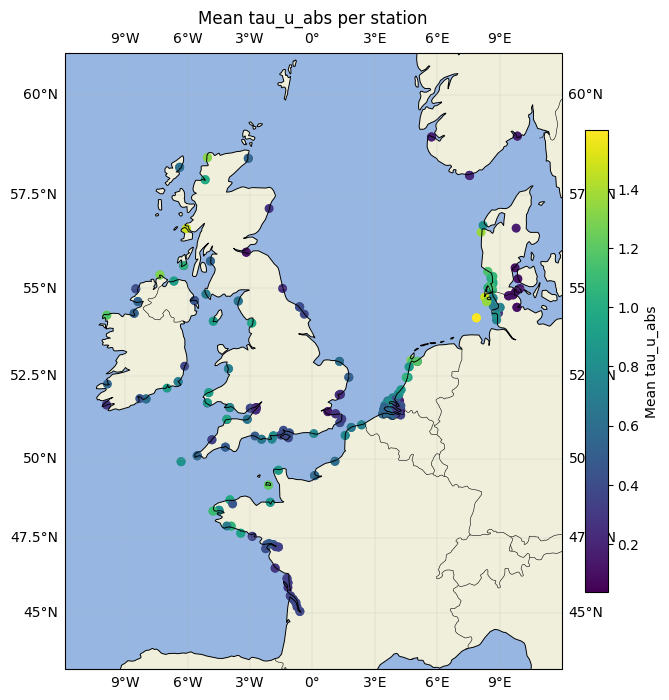

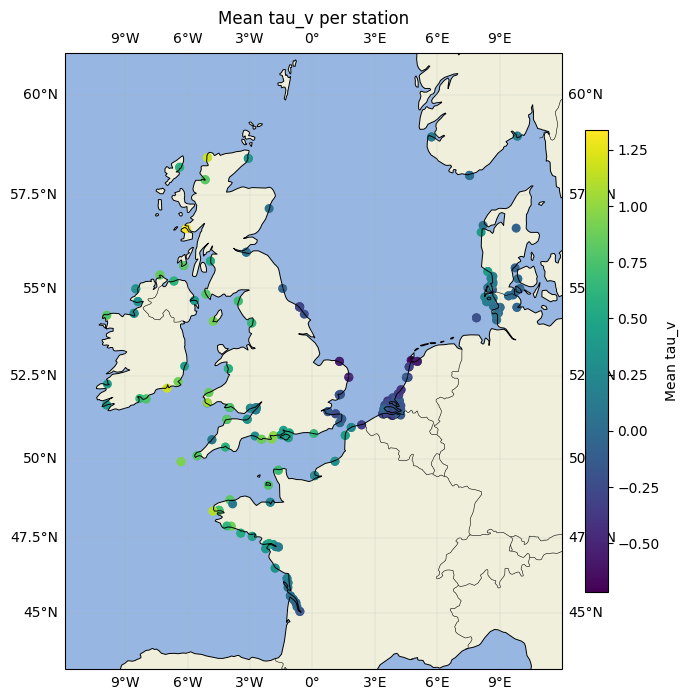

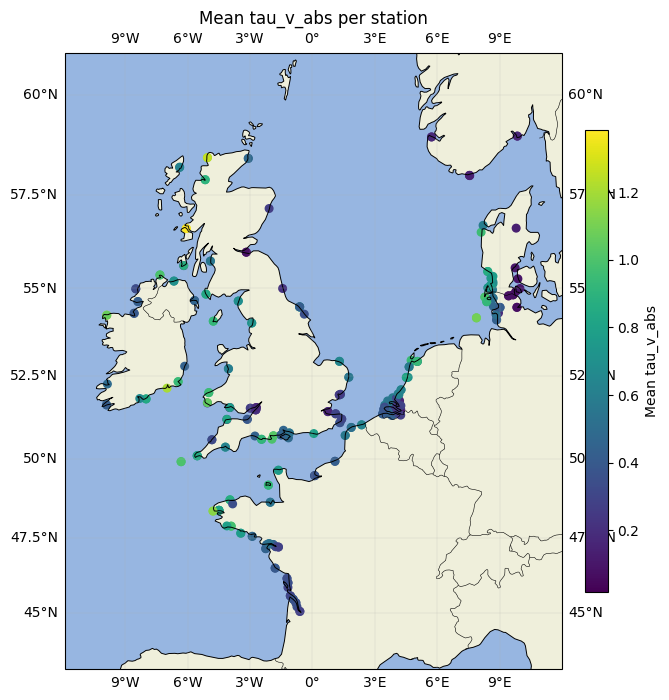

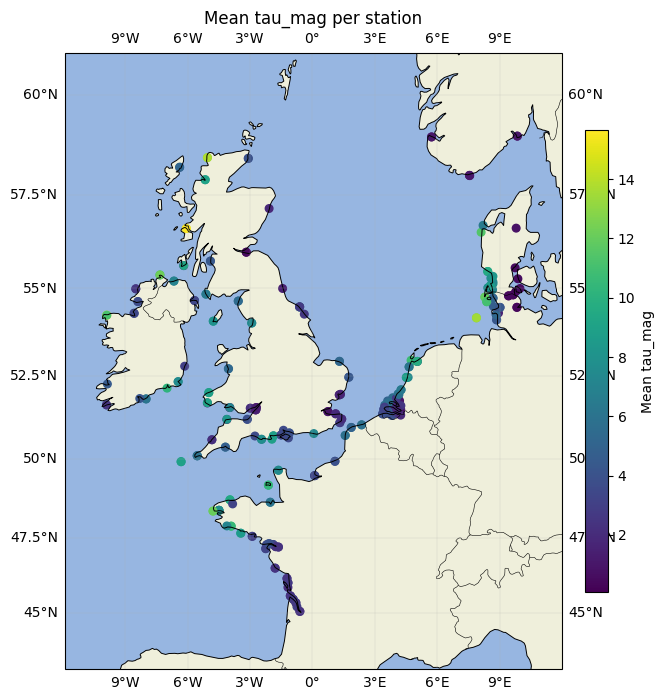

AttributeError: 'DataFrame' object has no attribute 'name'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_stat(col, stats_df, station_col="station"):
    # basic cleaning
    df = stats_df[[station_col, "lon", "lat", col]].copy()
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[station_col, "lon", "lat", col])

    # --- aggregate per station ---
    plot_df = (
        df.groupby(station_col)
          .agg({
              "lon": "mean",   # safe if constant per station
              "lat": "mean",
              col: "mean"
          })
          .reset_index()
    )

    # --- map ---
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(10, 8))
    ax = plt.axes(projection=ccrs.Mercator())

    pad = 2
    ax.set_extent(
        [plot_df["lon"].min()-pad, plot_df["lon"].max()+pad,
         plot_df["lat"].min()-pad, plot_df["lat"].max()+pad],
        crs=proj
    )

    ax.add_feature(cfeature.LAND, zorder=0)
    ax.add_feature(cfeature.OCEAN, zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

    sc = ax.scatter(
        plot_df["lon"], plot_df["lat"],
        c=plot_df[col],
        s=30,
        transform=proj
    )

    cb = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.03)
    cb.set_label(f"Mean {col}")

    ax.set_title(f"Mean {col} per station")
    plt.show()

for variable in list(stats_df.columns)[4:]:
    plot_stat(variable, stats_df)